# Visualize posterior

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
import os
import scipy.io
import xarray as xr
sys.path.append('../')

from src.utilities import low_high_percentile

# bedmap load in
bedmap_path = "/home/donglaiyang/Documents/Georgia-Tech/Research/common-data-set/bed-topography/bedmap3AIS.nc"
bedmap_ds = xr.open_dataset(bedmap_path)
bedmap_x = bedmap_ds['x'].values
bedmap_y = bedmap_ds['y'].values
bedmap_s = bedmap_ds['surface_topography'].values

# posterior data load in
posterior_sample_path = "../data/posterior-hmc-samples/hmc_samples.npz"
posterior_samples = np.load(posterior_sample_path)
print(posterior_samples)

# load mask
data_path = os.getenv('DATA_PATH')
mask_path = data_path + 'training_mask_domain_continuous.mat'
model_bound_data = scipy.io.loadmat(mask_path)
model_bound_data = model_bound_data['in_domain_mask']


NpzFile '../data/posterior-hmc-samples/hmc_samples.npz' with keys: Tb_samples, posterior_mean_Tb, posterior_std_Tb, log_probs, Tpmp...


In [55]:
low_bound, high_bound = low_high_percentile(posterior_samples["Tb_samples"],
                                            posterior_samples["log_probs"], 
                                            low_percentile=5, high_percentile=95)

deg_to_low_bound  = (posterior_samples["Tpmp"] - low_bound).reshape(256, 256)
deg_to_high_bound = (posterior_samples["Tpmp"] - high_bound).reshape(256, 256)

# use mask to nan areas outside
deg_to_low_bound[model_bound_data == 0] = np.nan
deg_to_high_bound[model_bound_data == 0] = np.nan

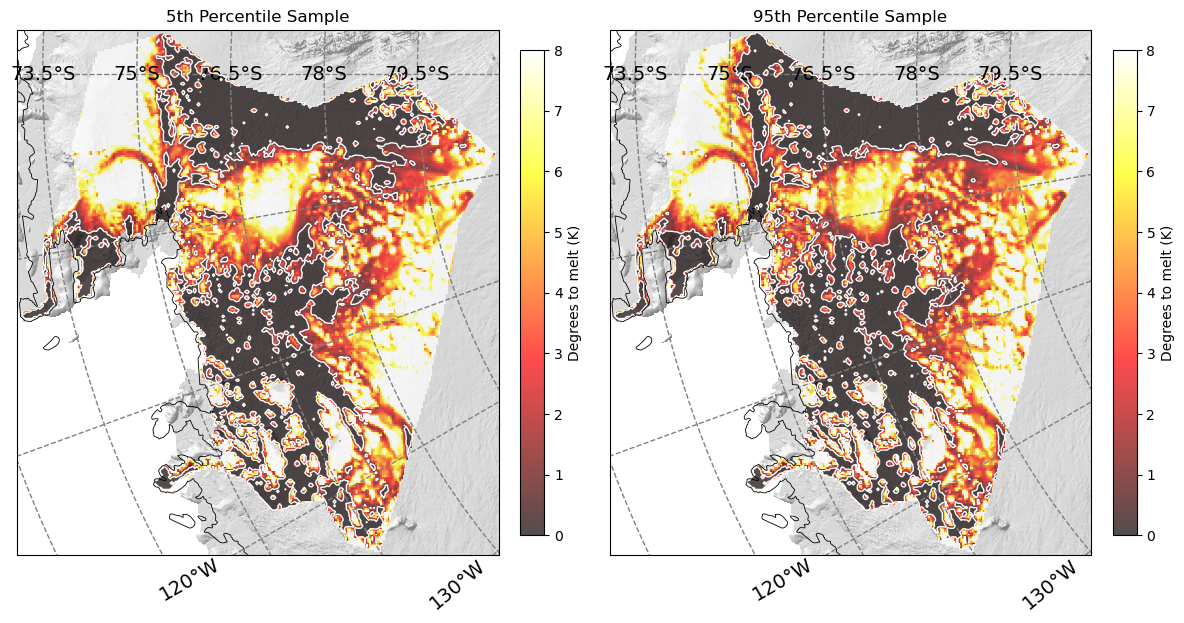

In [ ]:
proj     = ccrs.SouthPolarStereo()
data_crs = ccrs.epsg(3031)

fig, axes = plt.subplots(1, 2,
                         figsize=(12, 7),
                         subplot_kw={'projection': proj})

x_min, x_max = np.min(posterior_samples["x_coord"]), np.max(posterior_samples["x_coord"])
y_min, y_max = np.min(posterior_samples["y_coord"]), np.max(posterior_samples["y_coord"])

# preparing hillshade DEM
buffer = 50000  # 50 km buffer in meters
mask_x = (bedmap_x >= x_min - buffer) & (bedmap_x <= x_max + buffer)
mask_y = (bedmap_y >= y_min - buffer) & (bedmap_y <= y_max + buffer)
dem_crop = bedmap_s[np.ix_(mask_y, mask_x)]
x_crop   = bedmap_x[mask_x]
y_crop   = bedmap_y[mask_y]
# lightsource
ls = LightSource(azdeg=315, altdeg=45) 
hillshade = ls.hillshade(dem_crop,
                         vert_exag=20,
                         dx=np.abs(x_crop[1] - x_crop[0]),
                         dy=np.abs(y_crop[1] - y_crop[0]))

for ax in axes:
    ax.set_extent([x_min, x_max, y_min, y_max], crs=data_crs)
    ax.add_feature(cfeature.COASTLINE, zorder=3, edgecolor='black', linewidth=0.6)
    # Gridlines
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),       # gridlines are always defined in lon/lat
        draw_labels=True,
        linewidth=1,
        color='grey',
        alpha=0.8,
        linestyle='--',
        zorder=5                      # on top of everything
    )
    gl.top_labels    = False          # suppress crowded top labels
    gl.right_labels  = False
    gl.xlabel_style  = {'size': 10, 'color': 'black'}
    gl.ylabel_style  = {'size': 10, 'color': 'black'}


im0 = axes[0].imshow(
    deg_to_low_bound.reshape(256, 256),
    origin='lower',                        
    extent=[x_min, x_max, y_min, y_max], 
    transform=data_crs,
    cmap='hot', vmin=0, vmax=8,
    alpha=0.7,
    zorder=1
)
# axes[0].invert_yaxis()
axes[0].contour(
    np.linspace(x_min, x_max, 256),       # x coords
    np.linspace(y_min, y_max, 256),       # y coords
    deg_to_low_bound.reshape(256, 256),
    levels=[0.5], colors='white', linewidths=1,
    transform=data_crs, zorder=2
)
# add ice surface topography as hillshade 
axes[0].imshow(
    hillshade,
    origin='upper',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gray',
    alpha=0.5,
    zorder=0
)
axes[0].set_title("5th Percentile Sample")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label='Degrees to melt (K)')

# --- axes[1]: 95th percentile ---
im1 = axes[1].imshow(
    deg_to_high_bound.reshape(256, 256),
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=8,
    alpha=0.7,
    zorder=1
)
axes[1].contour(
    np.linspace(x_min, x_max, 256),
    np.linspace(y_min, y_max, 256),
    deg_to_high_bound.reshape(256, 256),
    levels=[0.5], colors='white', linewidths=1,
    transform=data_crs, zorder=2
)
# add ice surface topography as hillshade 
axes[1].imshow(
    hillshade,
    origin='upper',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='gray',
    alpha=0.5,
    zorder=0
)
axes[1].set_title("95th Percentile Sample")

fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
             label='Degrees to melt (K)')

plt.tight_layout()
plt.show()
